# **Laboratorio di introduzione all'apprendimento automatico - Lezione 1**

**Contatti**

Silvia Zandoli - Ph.D student @ Unibo - Computer Science and Engineering

*   email per chiarimenti: silvia.zandoli3@unibo.it



**Struttura delle lezioni:**

4 Lezioni da 2 ore ciascuna. 10 minuti di pausa per ogni lezione.


**Contenuti del corso:**

Prima parte
*   Lezione 1 - SkitLearn e Tasks supervisionati.
*   Lezione 2 - Tasks non supervisionati.

Seconda parte

*   Lezione 3 - TensorFlow e Keras: my first neural network, transfer learning
*   Lezione 4 - U-Net e segmentazione


### **Obiettivi di oggi**
1. SkitLearn e Tasks supervisionati

# Scikit-Learn
Scikit-learn è una libreria open source per Python che mette a disposizione numerose classi e funzionalità specifiche per il Machine Learning. Oltre a rendere disponibili i più comuni algoritmi per la classificazione, regressione e clustering, sono presenti anche diverse funzionalità per la manipolazione dei dati.

La popolarità di Scikit-learn è dovuta principalmente alla sua facilità d'uso, all'integrazione con la libreria Numpy e alla possibilità di parametrizzare le operazioni messe a disposizione, pur mantenendo una API semplice.

Per una lista completa delle funzionalità si rimanda alla [documentazione ufficiale](https://scikit-learn.org/stable/index.html).

In [ ]:
import sklearn

# Supervised Learning
Nel supervised learning, l'algoritmo impara a svolgere un compito basandosi su esempi etichettati forniti durante il training. Questi esempi etichettati consistono in coppie *input-output*, dove l'input sono i dati (*features* o variabili indipendenti) e l'output è l'etichetta o variabile **target** corrispondente (variabile dipendente). L'obiettivo del supervised learning è generalizzare dagli esempi forniti per fare predizioni accurate su dati nuovi e mai visti. Poiché gli algoritmi di supervised learning sono focalizzati sull'apprendimento di un compito specifico o predizione, sono spesso chiamati '**task-driven**' (guidati dal compito). Questo termine enfatizza che il processo di apprendimento dell'algoritmo ruota attorno al completamento di un compito predefinito, guidato dai dati etichettati.
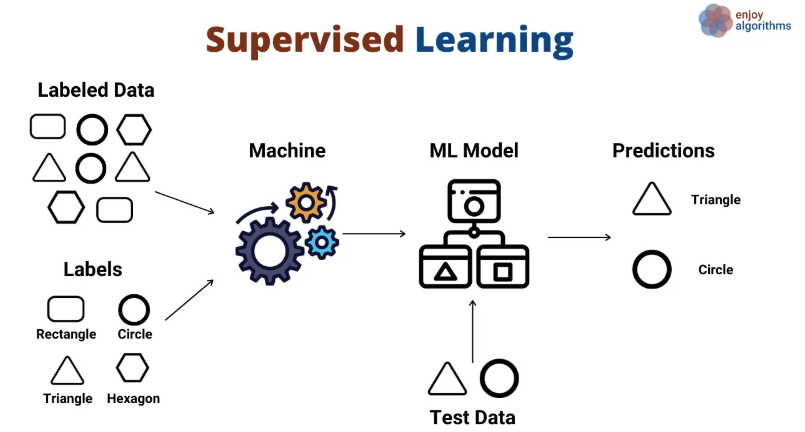

Tra questi distinguiamo:

### 1️⃣ REGRESSIONE
**Prevede valori numerici continui**

Esempi nella vita reale:
- 🏠 Prezzo di una casa (€150.000, €200.000...)
- 📈 Valore delle azioni ($45.50, $46.20...)
- 🌡️ Temperatura di domani (22.5°C, 23.1°C...)
- ⚡ Consumo elettrico mensile (350 kWh, 420 kWh...)

### 2️⃣ CLASSIFICAZIONE
**Prevede valori categorici**

Esempi nella vita reale:
- 📧 Email: Spam o Non Spam
- 🏥 Diagnosi: Malato o Sano
- 💳 Transazione: Fraudolenta o Legittima
- 😊😐😢 Sentiment Analysis: Positivo, Neutro o Negativo

# Regressione
**Matematicamente** la regressione può essere intesa come il trovare la funzione che meglio approssima la relazione tra la variabile dipendente X (l'input) e la variabile indipendente Y (l'output). Nel caso di una regressione lineare questa funzione è un polinomio.

$$ f(x)=xw+b $$

**Graficamente** questa relazione lineare può essere rappresentata come una retta che passa il più vicino possibile a tutti i punti costituiti da input X e output Y.

### Predire il valore di un'abitazione
Per questo primo esempio utilizzeremo il popolarissimo Boston Housing Dataset, un dataset contenente diverse informazioni riguardo alcune abitazioni nei dintorni di Boston.

**Pandas** è una libreria Python sviluppata appositamente per chi lavora con i dati e mette a disposizione una particolare struttura dati chiamata DataFrame che si presta particolarmente bene a contenere dati in forma tabulare.

Carichiamo il Boston Housing Dataset all'interno di un DataFrame utilizzando la funzione read_csv , seguita dal metodo head del DataFrame per vedere le sue prime 5 righe.

In [ ]:
import pandas as pd

boston = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data",
                     sep='\s+', #le colonne all'interno del file sono separate da un numero variabile di spazi, in questo caso dobbiamo utilizzare l'espressione regolare '\s+'
                     names=["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","TAX","PRATIO","B","LSTAT","MEDV"]) # impostiamo dei nomi per le colonne

boston.head() # passando un valore n a questo metodo stamperemo i primi n esempi del dataset


CRIM – tasso di criminalità pro capite per città
ZN – proporzione di terreni residenziali destinati a lotti superiori a 25.000 piedi quadrati
INDUS – proporzione di acri destinati ad attività non commerciali per città
CHAS – variabile dummy relativa al fiume Charles (1 se il lotto confina con il fiume; 0 altrimenti)
NOX – concentrazione di ossidi di azoto (parti per 10 milioni)
RM – numero medio di stanze per abitazione
AGE – proporzione di unità abitative occupate dal proprietario costruite prima del 1940
DIS – distanze ponderate da cinque centri di impiego di Boston
RAD – indice di accessibilità alle autostrade radiali
TAX – aliquota dell’imposta catastale sul valore pieno per ogni 10.000 $
PTRATIO – rapporto alunni/insegnanti per città
B – 1000(Bk – 0,63)², dove Bk è la proporzione di persone di colore per città
LSTAT – percentuale di popolazione con status socioeconomico basso

La colonna che abbiamo denominato MEDV contiene il valore dell'abitazione in `1000$` (es. un MEDV di 24 corrisponde a `24000$`) ed è il nostro target.

Esploriamo meglio il dataset

In [ ]:
boston.describe()

In [ ]:
# distribuzioni features (istogrammi)
import matplotlib.pyplot as plt
boston.hist(bins=50, figsize=(20,15))
plt.show()

In [ ]:
X = boston.drop("MEDV", axis=1).values # utilizzando drop rimuoviamo la colonna del prezzo e selezioniamo tutte le altre
Y = boston["MEDV"].values

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.3, random_state=0) #Split the data into training and testing sets:

Quando lavoriamo con più features dobbiamo essere sicuri che queste siano comprese in un range di valori comune, per far questo abbiamo due possibilità:
* **Normalizzazione**: portiamo tutti i dati in un range compreso tra 0 e 1
   * **MinMaxScaler()** -> z = (x-x_min)/(x_max-x_min) : range [0,1]
   * MaxAbsScaler() -> z = x / Abs(x_max) : range [-1,1]
* **Standardizzazione**: convertiamo i dati in una distribuzione normale con media 0 e deviazione standard 1.
    *   StandardScaler() ->z = (x - u) / s

Un altro scaler importante è log normalization.

Standardizziamo l'array con le features utilizzando la classe StandardScaler di scikit-learn

In [ ]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train_std = ss.fit_transform(X_train)
X_test_std = ss.transform(X_test)

Adesso abbiamo tutto ciò che ci serve per costruire il modello di regressione lineare, facciamolo utilizzando la classe LinearRegression di scikit-learn:
 * con il metodo **fit** eseguiamo l'addestramento
 * con il metodo **predict** eseguiamo la predizione

In [ ]:
from sklearn.linear_model import LinearRegression

ll = LinearRegression()
ll.fit(X_train_std, Y_train)
Y_pred_train = ll.predict(X_train_std)
Y_pred_test = ll.predict(X_test_std)

 Adesso bisogna vedere quanto buono è questo modello.
Per farlo dobbiamo definire una metrica che ci permetterà di misurare quanto le predizioni del modello si avvicinano ai valori corretti.
Una metrica semplice che fa proprio questo è l'**errore quadratico medio (mean squared error - MSE)**

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
print("MSE train: %f" % mean_squared_error(Y_train, Y_pred_train))
print("MSE test: %f" % mean_squared_error(Y_test, Y_pred_test))

print("R2 train: %f" % r2_score(Y_train, Y_pred_train))
print("R2 test: %f" % r2_score(Y_test, Y_pred_test))

Estraendo la radice quadrata dell'MSE otteniamo l'**RMSE** (Root Mean Squared Error), un valore che indica mediamente di quanto si è sbagliato il modello nelle sue previsioni, espresso nella stessa unità di misura del target.

La radice quadrata di 27.20 è circa 5.21.

In [ ]:
import numpy as np
rmse = np.sqrt( mean_squared_error(Y_test, Y_pred_test))
print(rmse)

5.214975145375402


Poichè i prezzi delle case sono espressi in `1000$`, questo ci dice che in media il modello si è sbagliato di circa `5.210$` nella previsione del prezzo di una casa mai vista.

Una metrica più intuitiva è il coefficiente di indeterminazione (anche conosciuto come punteggio R2), che può essere inteso come una versione standardizzata del MSE e ritorna un valore compreso tra 0 e 1 che può essere letto in questo modo:

R2_score < 0.3 il modello è inutile.

*   0.3 < R2_score < 0.5 il modello è scarso.
*   **0.5 < R2_score < 0.7 il modello è discreto.**
*   0.7 < R2_score < 0.9 il modello è buono.
*   0.7 < R2_score < 0.9 il modello è buono.
*   R2_score = 1 molto probabilmente c'è un errore nel modello.




In [ ]:
import matplotlib.pyplot as plt

# Grafico per il TEST SET
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, Y_pred_test, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Prezzi Reali ($1000)')
plt.ylabel('Prezzi Predetti ($1000)')
plt.title('Regressione Multipla: Valori Reali vs Predetti (Test Set)')
plt.grid(True, alpha=0.3)
plt.show()

# Classificazione

La classificazione è una tecnica utilizzata nell’apprendimento con supervisione dove l’obiettivo, in base alle analisi di dati precedentemente etichettati, è quello di riuscire a prevedere l’etichettatura delle classi di dati future. Le etichette sono valori discreti non ordinati che possono essere considerati appartenenti a un gruppo di una classe.

In figura si può vedere il compito di classificazione binaria basato su di un campione d’apprendimento. Per quanto riguarda i cerchi abbiamo una classe negativa, mentre per le X abbiamo una classe positiva. In questo esempio abbiamo a disposizione un dataset bidimensionale.

Ad ogni campione vengono associati due colori x1x1 e x2x2.

Utilizzando un algoritmo d’apprendimento automatico con supervisione, per avere un confine decisionale, saremo in grado di separare le due classi ed ad associare i dati, sulla base dei loro valori, alle due diverse categorie.

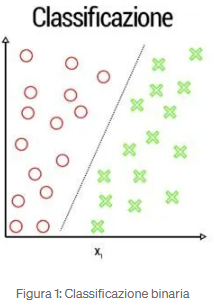

### Balancing
**[imbalanced-learn](https://imbalanced-learn.org/stable/)** è una libreria di scikit learn che permette di gestire le classi non bilanciate nei problemi di classificazione

In [ ]:
!pip install imbalanced-learn

Undersampling. si riducono gli esempi della classe maggioritaria.

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from imblearn.under_sampling import RandomUnderSampler,NearMiss



# Genera un dataset sbilanciato di esempio
X, y = make_classification(
    n_classes=2,
    class_sep=2,
    weights=[0.1, 0.9],
    n_informative=3,
    n_redundant=1,
    flip_y=0,
    n_features=5,
    n_clusters_per_class=1,
    n_samples=1000,
    random_state=42)

# Applica Il metodo per l'undersampling
undersampler = RandomUnderSampler(sampling_strategy='auto', random_state=42) # balance the data by randomly selecting a subset of data for the targeted classes
#undersampler = NearMiss(sampling_strategy='auto', version=2, n_neighbors=3) #heuristic rules are based on nearest neighbors algorithm.

X_resampled, y_resampled = undersampler.fit_resample(X, y)

# Plotta il dataset originale e il dataset resampled
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='Set1', marker='o')
plt.title('Dataset originale')

plt.subplot(1, 2, 2)
plt.scatter(X_resampled[:, 0], X_resampled[:, 1], c=y_resampled, cmap='Set1', marker='o')
plt.title('Dataset Ricampionato')

plt.tight_layout()
plt.show()


Oversampling – si aumentano gli esempi della classe minoritaria.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from imblearn.over_sampling import ADASYN,SMOTE

# Genera un dataset sbilanciato di esempio
X, y = make_classification(n_classes=2, class_sep=2, weights=[0.1, 0.9], n_informative=3, n_redundant=1, flip_y=0, n_features=5, n_clusters_per_class=1, n_samples=1000, random_state=42)

#generate new samples by interpolation
# Applica SMOTE per l'oversampling
oversampler_adasyn = ADASYN(sampling_strategy='auto', random_state=42, n_neighbors=6) #Crea esempi sintetici per la classe minoritaria, focalizzandosi su aree "difficili"
oversampler_smote = SMOTE(sampling_strategy='auto', random_state=42)

X_adasyn_resampled, y_adasyn_resampled = oversampler_adasyn.fit_resample(X, y)
X_smote_resampled, y_smote_resampled = oversampler_smote.fit_resample(X, y)


# Plotta il dataset originale e il dataset resampled
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='Set1', marker='o')
plt.title('Dataset originale')

plt.subplot(1, 3, 2)
plt.scatter(X_adasyn_resampled[:, 0], X_adasyn_resampled[:, 1], c=y_adasyn_resampled, cmap='Set1', marker='o')
plt.title('Dataset Ricampionato con ADASYN')

plt.subplot(1, 3, 3)
plt.scatter(X_smote_resampled[:, 0], X_smote_resampled[:, 1], c=y_smote_resampled, cmap='Set1', marker='o')
plt.title('Dataset Ricampionato con SMOTE')

plt.tight_layout()
plt.show()


## Classificazione binaria

In [ ]:
from sklearn import preprocessing
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

#dataset generation

from sklearn.datasets import make_blobs,make_moons,make_s_curve,make_circles
import matplotlib.pyplot as plt

n_samples = 1000
n_features = 2
n_classes = 2
seed = 42
noise_factor = 0.1
np.random.seed(seed)

# Genera il dataset con make_blobs
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_classes, random_state=seed,  )#cluster_std=[1.,2.]
#X, y = make_moons(n_samples=n_samples, noise=noise_factor, random_state=seed)
#X, y = make_circles(n_samples=n_samples, noise=noise_factor, factor=0.1, random_state=seed)


## Data preprocessing
# Creiamo un dataset di esempio con due classi in proporzione diversa
scaler = preprocessing.MinMaxScaler() # range [0,1]
scaler.fit(X)
X = scaler.transform(X)


#mostro la distribuzione del dataset a video
plt.scatter( X[:,0], X[:,1], c=y, cmap="viridis")
plt.show()



Scikit-learn mette a disposizione una serie di classificatori tra cui [k-NN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html), [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html), [Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) e [Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html#naive-bayes).

Tra quelli non visti a lezione:


*   k_NN il KNN classifier funziona trovando i K vicini più vicini a un nuovo punto di dati e quindi votando per la classe più comune tra questi vicini.
*   Support Vector Classifier . Il suo obiettivo principale è trovare un iperpiano ottimale nello spazio delle feature che separi i diversi gruppi di dati (classi) con il massimo margine possibile








**Alcune note:**

Splitting stratificato (stratify) : è una pratica raccomandata quando si lavora con dataset di machine learning, specialmente quando ci sono classi sbilanciate. La sua importanza risiede nel fatto che assicura che i dati di test riflettano accuratamente la distribuzione dei dati reali, contribuendo così a mantenere la rappresentatività dei dati di addestramento anche nel test set. Questo migliora la generalizzazione del modello, previene il bias nell'apprendimento e consente di valutare in modo equo le prestazioni del modello.

In [ ]:
#importiamo i modelli da scikit learn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Esegui uno splitting stratificato
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed) #stratify è importante

# Crea i modelli
# Creazione del modello di regressione logistica
model_logistic = LogisticRegression(
    penalty='l2',     # Tipo di regolarizzazione (l1 o l2)
    C=1.0,            # Inverso della forza di regolarizzazione
    random_state=42   # Seed per la riproducibilità
)


# Creazione del modello GaussianNB
model_naive_bayes = GaussianNB()


# Creazione del modello dell'albero decisionale con parametri personalizzati
model_decision_tree = DecisionTreeClassifier(
    criterion='entropy',  # Criterio per la suddivisione ('gini' o 'entropy')
    max_depth=None,       # Profondità massima dell'albero
    min_samples_split=2,  # Numero minimo di campioni richiesti per suddividere un nodo
    min_samples_leaf=1,   # Numero minimo di campioni richiesti in una foglia
    max_features=None,    # Numero di caratteristiche da considerare per la divisione
    random_state=seed     # Seed per la riproducibilità
)

model_knn = KNeighborsClassifier(
    n_neighbors=5          # il numero di vicini più prossimi
)
model_svc = SVC(
    kernel="rbf",         #funzione di kernel rbf o linear
    C=1,                  #parametri di regolarizzazione
    gamma=0.1
)


# Addestramento dei modelli

model_logistic.fit(X,y)
model_naive_bayes.fit(X,y)
model_decision_tree.fit(X,y)
model_knn.fit(X, y)
model_svc.fit(X, y)

In [ ]:
#vediamo cosa hanno imparato

# Predici le classi per i dati di test
y_pred_logistic = model_logistic.predict(X_test)
y_pred_naive_bayes = model_naive_bayes.predict(X_test)
y_pred_decision_tree = model_decision_tree.predict(X_test)
y_pred_svc=model_svc.predict(X_test)
y_pred_knn=model_knn.predict(X_test)

# # Crea un meshgrid per visualizzare la decision boundary
x_min = X_test[:, 0].min() - 0.1
x_max = X_test[:, 0].max() + 0.1

xv = np.linspace(x_min,x_max, 500) # Questi valori rappresentano 500 punti lungo l'asse delle ascisse (X).
yv = np.linspace(x_min,x_max, 500) # Questi valori rappresentano 500 punti lungo l'asse delle ordinate (Y).

xx, yy = np.meshgrid(yv,xv) # creare un meshgrid bidimensionale.
# xx contiene i punti X della matrice XY lungo l'asse X
# yy conterrà i punti Y della matrice XY lungo l'asse Y


# Visualizza le decision boundary dei tre modelli
models = {
    'Logistica': model_logistic,
    'Naive Bayes': model_naive_bayes,
    'Decision Tree': model_decision_tree,
    'k-NN': model_knn,
    'SVC': model_svc
}

# Meshgrid corretto
x_min, x_max = X_test[:, 0].min() - 0.1, X_test[:, 0].max() + 0.1
y_min, y_max = X_test[:, 1].min() - 0.1, X_test[:, 1].max() + 0.1
xv, yv = np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500)
xx, yy = np.meshgrid(xv, yv)

plt.figure(figsize=(25, 6))
for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(1, 5, i)
    zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.contourf(xx, yy, zz, cmap=plt.cm.Set1, alpha=0.4)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.Set1, edgecolor='k')
    plt.title(name)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

plt.tight_layout()
plt.show()

## Classificazione multi classe

dataset IRIS.
[doc link](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris)

'Iris dataset è un dataset di esempio che contiene misurazioni di quattro caratteristiche di tre diverse specie di fiori Iris: Setosa, Versicolor e Virginica. Le quattro caratteristiche sono la lunghezza e la larghezza del sepalo e del petalo, misurate in centimetri.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
seed=42
iris_dataset_pd = load_iris(as_frame=True) #as_frame torna un oggetto che contiene
X = iris_dataset_pd.data   #è un DataFrame pandas
y= iris_dataset_pd.target  #è un Series pandas
classes_dict = ['Setosa','Versicolor','Virginica']

print(f"Input features are: { X.columns.tolist() }, shape { X.shape }")
print(f"Output features are: { y.unique().tolist()}")
print(f"Output label are: { classes_dict }")

#Data preprocessing
scaler = preprocessing.MinMaxScaler() # range [0,1]
scaler.fit(X)
X = scaler.transform(X)

#Data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed) #stratify è importante

#Training
# Crea i modelli
# Creazione del modello di regressione logistica
model_logistic = LogisticRegression(
    penalty='l2',     # Tipo di regolarizzazione (l1 o l2)
    C=1.0,            # Inverso della forza di regolarizzazione
    random_state=42   # Seed per la riproducibilità
)


# Creazione del modello GaussianNB
model_naive_bayes = GaussianNB()


# Creazione del modello dell'albero decisionale con parametri personalizzati
model_decision_tree = DecisionTreeClassifier(
    criterion='entropy',  # Criterio per la suddivisione ('gini' o 'entropy')
    max_depth=None,       # Profondità massima dell'albero
    min_samples_split=2,  # Numero minimo di campioni richiesti per suddividere un nodo
    min_samples_leaf=1,   # Numero minimo di campioni richiesti in una foglia
    max_features=None,    # Numero di caratteristiche da considerare per la divisione
    random_state=seed     # Seed per la riproducibilità
)

model_knn = KNeighborsClassifier(
    n_neighbors=5          # il numero di vicini più prossimi
)
model_svc = SVC(
    kernel="rbf",         #funzione di kernel rbf o linear
    C=10,                  #parametri di regolarizzazione
    gamma=0.05
)


# Addestramento dei modelli

model_logistic.fit(X_train,y_train)
model_naive_bayes.fit(X_train,y_train)
model_decision_tree.fit(X_train,y_train)
model_svc.fit(X_train, y_train)
model_knn.fit(X_train, y_train)



### Grid-Search e Cross-Validation

la **cross‑validation** consiste nel suddividere il dataset in più sottoinsiemi (fold) e nel ripetere più volte l’addestramento e la valutazione del modello su diverse combinazioni di questi sottoinsiemi.
L’obiettivo è stimare come il modello si comporterà su dati nuovi, mai visti durante l’addestramento, riducendo la dipendenza da una singola suddivisione train/test.

Dato un algoritmo, la ricerca degli iperparametri ottimi può essere automatizzata utilizzando la classe **GridSearchCV** messa a disposizione da Scikit-learn.

Questo metodo è particolarmente indicato nei casi in cui l'addestramento di un classificatore non richieda un tempo particolarmente lungo. Si consideri infatti che vengono creati e addestrati (**# combinazioni degli iperparametri×# fold)+1 classificatori.**

In [ ]:
from sklearn.model_selection import cross_val_score, GridSearchCV, ParameterGrid, train_test_split
# Creazione di un classificatore di tipo SVM
clf = SVC()

# Creazione della griglia di iperparametri
param_grid = [{'kernel': ['rbf'], 'C': [1,10], 'gamma': [0.05,0.025]}] #C parametro di regolarizzazione, kernel rbf o linear

# Numero di fold per la Cross-validation
n_folds = 5

# Creazione di un oggetto di tipo GridSearchCV
grid_search_cv = GridSearchCV(clf, param_grid, cv=n_folds)

# Esecuzione della ricerca degli iperparametri
grid_search_cv.fit(X_train, y_train) #ottimizzazione iperparametri

# Stampa risultati
print('Combinazioni di parametri:\n', grid_search_cv.cv_results_['params'])
print('Accuratezza media per combinazione:\n', grid_search_cv.cv_results_['mean_test_score'])
print('Combinazione migliore:\n', grid_search_cv.best_params_)
print('Accuratezza media della combinazione migliore: %.3f' % grid_search_cv.best_score_)


**K-Fold** è una tecnica di cross-validation che divide il dataset in k parti uguali (folds), addestra il modello su k−1 folds e testa su 1 fold, ripetendo k volte. **Stratified K-Fold** è una variante avanzata di K-Fold che mantiene la proporzione delle classi in ogni fold.
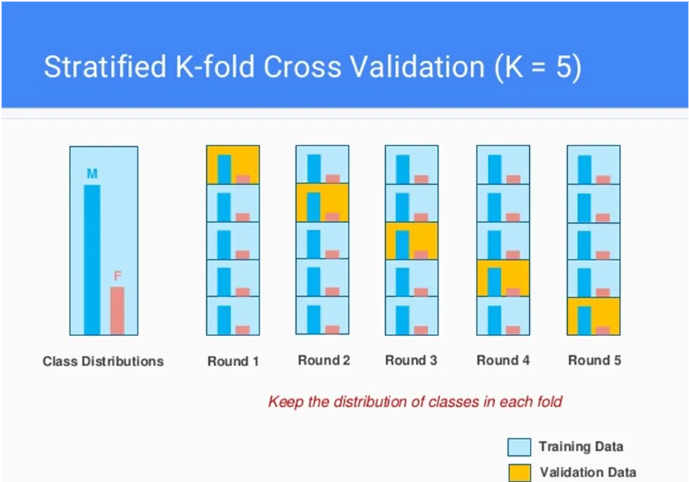

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt

# Definisci i modelli
modelli = [
    ("Regressione Logistica", model_logistic),
    ("Naive Bayes", model_naive_bayes),
    ("Albero Decisionale", model_decision_tree),
    ("k-NN", model_knn),
    ("SVC", model_svc)
]

# Imposta il numero di fold
k = 5

# Crea oggetti StratifiedKFold per la cross-validation
cv = StratifiedKFold(n_splits=k)

# Crea una figura per i subplot
plt.figure(figsize=(15, 5))

# Itera attraverso i modelli
for i, (nome_modello, modello) in enumerate(modelli, 1):

    # Calcola i risultati della cross-validation per il modello corrente
    results = cross_val_score(modello, X_train, y_train, cv=cv)

    # Crea un subplot per il modello corrente
    plt.subplot(1, len(modelli), i)

    # Plotta i risultati
    plt.bar(range(1, k+1), results)
    plt.xlabel('Fold')
    plt.ylabel('Accuracy')
    plt.title(f'{nome_modello}')
    plt.ylim(0.8, 1.0)

# Aggiungi titolo alla figura
plt.suptitle('Risultati K-Fold Cross-Validation per Diversi Modelli', y=1.02)

# Mostra i subplots
plt.tight_layout()
plt.show()

se ci sono differenze significative fra le accuracy dei vari fold vuol dire che il modello ha prestazioni variabili su diversi fold o che alcuni fold sono più difficili da predire rispetto ad altri.

In [ ]:
#valutiamo chi ha fatto meglio con la matrice di confusione e tutte le sue metriche
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


def confronta_modelli(X_test, y_test, modelli):

    fig, axes = plt.subplots(1, len(modelli), figsize=(15, 5))  # Crea una riga di grafici
    results = []
    for i, (nome_modello, modello) in enumerate(modelli):
      y_pred = modello.predict(X_test)

      accuracy = accuracy_score(y_test, y_pred)
      precision = precision_score(y_test, y_pred, average="macro")
      recall = recall_score(y_test, y_pred, average="macro")
      f1 = f1_score(y_test, y_pred, average="macro")
      conf_matrix = confusion_matrix(y_test, y_pred)
      # Plotta la matrice di confusione
      ConfusionMatrixDisplay(conf_matrix, display_labels=['Setosa','Versicolor','Virginica']).plot(ax=axes[i] )
      axes[i].set_title(f"Matrice di Confusione - {nome_modello}")

      risultato_modello = {
            "Modello": nome_modello,
            "Accuratezza": accuracy,
            "Precisione": precision,
            "Recall": recall,
            "F1-Score": f1
      }

      results.append(risultato_modello)

    results_df = pd.DataFrame(columns=["Modello", "Accuratezza", "Precisione", "Recall", "F1-Score"], data=results)

    print(results_df.to_markdown(index=False))
    # Mostra i subplot
    plt.tight_layout()
    plt.show()


modelli = [
    ("LR", model_logistic),
    ("NB", model_naive_bayes),
    ("DT", model_decision_tree),
    ("k-NN", model_knn),
    ("SVC", model_svc)
]

# Ottieni i risultati delle metriche per tutti i modelli
confronta_modelli(X_test, y_test, modelli)

**Accuracy** (Accuratezza): L'accuracy è una misura della percentuale di previsioni corrette fatte dal modello rispetto al numero totale di previsioni.

$$
Accuracy = \frac{Numero\ di\ previsioni\ corrette}{Numero\ totale\ di\ previsioni}
$$

**Precision** (Precisione):Si concentra sulla percentuale di previsioni positive fatte dal modello che erano effettivamente corrette.

$$
Precision = \frac{True\ Positives}{True\ Positives + False\ Positives}
$$


**Recall** (Recall o True Positive Rate): Il recall è una misura della frazione di esempi positivi reali che sono stati correttamente previsti dal modello.

$$
Recall = \frac{True\ Positives}{True\ Positives + False\ Negatives}
$$


**F1-Score** (F1-Score o F1 Measure): Il F1-Score è una metrica che combina precisione e recall in un'unica misura. È il valore medio armonico tra precisione e recall.

$$
F1-Score = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$